# 13 Stocks EDA

This notebook is designed to understand the **stocks / market view itself** so it can support three downstream purposes:

1. **Snorkel labeling functions**  
2. **Imputation decisions**  
3. **Feature engineering / modeling decisions**

It focuses on understanding the variables, missingness structure, distributional behavior, and whether features are suitable for:
- interpretable weak rules
- imputation
- later modeling

## Imports and project path setup

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print("project_root:", project_root)
print("src_path:", src_path)

project_root: /Users/Thomas/Desktop/Master Thesis
src_path: /Users/Thomas/Desktop/Master Thesis/src


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from master_thesis.data_utils import load_raw, save_processed

## Load stocks data

Update the filename below if needed.

In [3]:
df_stocks = load_raw("Stock_view.csv", low_memory=False)

print("Shape:", df_stocks.shape)
display(df_stocks.head())

Shape: (30288, 27)


,Unnamed: 0,BvD ID number,Company name Latin alphabet,Year,avg_vol,std_vol,max_vol,min_vol,vol_stability_score,vol_shock_ratio,...,Price_trends_52 weeks_%,market_beta_1y,Earnings_per_share_DKK,Book_value_per_share_DKK,Shares outstanding,Current_market_capitalisation_DKK,avg_closing_price,price_volatility_score,price_trend_slope,Risk level_stock_closing_price
0,0,AE0001327927,Rever Events L.L.C,2011,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,n.a.,n.a.,NaN,NaN,NaN,Take caution
1,1,AE0001327927,Rever Events L.L.C,2012,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,n.a.,n.a.,NaN,NaN,NaN,Take caution
2,2,AE0001327927,Rever Events L.L.C,2013,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,n.a.,n.a.,NaN,NaN,NaN,Take caution
3,3,AE0001327927,Rever Events L.L.C,2014,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,n.a.,n.a.,NaN,NaN,NaN,Take caution
4,4,AE0001327927,Rever Events L.L.C,2015,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,n.a.,n.a.,NaN,NaN,NaN,Take caution


## Standardize key column names

This makes the EDA more consistent with later feature engineering.

In [4]:
df_stocks = df_stocks.copy()

rename_map = {
    "BvD ID number": "moodys_bvd_id",
    "Join_Year": "join_year",
    "Company name Latin alphabet": "company_name_latin_alphabet",
    "Risk level": "risk_level",
}

rename_map = {k: v for k, v in rename_map.items() if k in df_stocks.columns}
df_stocks = df_stocks.rename(columns=rename_map)

df_stocks = df_stocks.drop(columns=["Unnamed: 0"], errors="ignore")

if "moodys_bvd_id" in df_stocks.columns:
    df_stocks["moodys_bvd_id"] = df_stocks["moodys_bvd_id"].astype("string").str.strip()

if "join_year" in df_stocks.columns:
    df_stocks["join_year"] = pd.to_numeric(df_stocks["join_year"], errors="coerce").astype("Int64")

print("Shape:", df_stocks.shape)
print("Columns:")
print(df_stocks.columns.tolist())

Shape: (30288, 26)
Columns:
['moodys_bvd_id', 'company_name_latin_alphabet', 'Year', 'avg_vol', 'std_vol', 'max_vol', 'min_vol', 'vol_stability_score', 'vol_shock_ratio', 'vol_trend_slope', 'join_year', 'risk_level', 'avg_market_cap', 'market_cap_volatility', 'supplier_sector', 'moodys_risk_rating', 'Price_trends_52 weeks_%', 'market_beta_1y', 'Earnings_per_share_DKK', 'Book_value_per_share_DKK', 'Shares outstanding', 'Current_market_capitalisation_DKK', 'avg_closing_price', 'price_volatility_score', 'price_trend_slope', 'Risk level_stock_closing_price']


## Basic structure overview

In [5]:
df_structure = pd.DataFrame({
    "feature": df_stocks.columns,
    "dtype": df_stocks.dtypes.astype(str).values,
    "missing_pct": df_stocks.isna().mean().values * 100,
    "n_unique": df_stocks.nunique(dropna=True).values,
}).sort_values(["missing_pct", "n_unique"], ascending=[False, True]).reset_index(drop=True)

display(df_structure)
print("Total features:", len(df_structure))

,feature,dtype,missing_pct,n_unique
0,vol_stability_score,float64,96.503566,1056
1,vol_trend_slope,float64,96.503566,1057
2,std_vol,float64,96.500264,1056
3,market_cap_volatility,float64,96.500264,1060
4,price_volatility_score,float64,96.500264,1060
5,price_trend_slope,float64,96.500264,1060
6,min_vol,float64,96.487058,1051
7,max_vol,float64,96.487058,1053
8,vol_shock_ratio,float64,96.487058,1053
9,avg_vol,float64,96.487058,1059


Total features: 26


## Candidate stocks columns

This separates likely numeric market variables from identifiers / descriptive text.

In [6]:
id_like_cols = [
    c for c in df_stocks.columns
    if c in {"moodys_bvd_id", "join_year", "company_name_latin_alphabet", "supplier_sector"}
    or "company_name" in c.lower()
    or "bvd" in c.lower()
]

numeric_candidate_cols = df_stocks.select_dtypes(include=["number"]).columns.tolist()
numeric_candidate_cols = [c for c in numeric_candidate_cols if c not in id_like_cols]

categorical_candidate_cols = [
    c for c in df_stocks.columns
    if c not in numeric_candidate_cols and c not in id_like_cols
]

print("Numeric candidate cols:", len(numeric_candidate_cols))
print("Categorical candidate cols:", len(categorical_candidate_cols))
print("ID-like cols:", id_like_cols)

Numeric candidate cols: 17
Categorical candidate cols: 5
ID-like cols: ['moodys_bvd_id', 'company_name_latin_alphabet', 'join_year', 'supplier_sector']


## Missingness overview

This is critical for both imputation and deciding whether a feature is usable at all.

In [7]:
df_missing = pd.DataFrame({
    "feature": df_stocks.columns,
    "missing_pct": df_stocks.isna().mean().values * 100,
    "n_missing": df_stocks.isna().sum().values,
    "dtype": df_stocks.dtypes.astype(str).values,
}).sort_values("missing_pct", ascending=False).reset_index(drop=True)

display(df_missing)

,feature,missing_pct,n_missing,dtype
0,vol_trend_slope,96.503566,29229,float64
1,vol_stability_score,96.503566,29229,float64
2,std_vol,96.500264,29228,float64
3,price_volatility_score,96.500264,29228,float64
4,market_cap_volatility,96.500264,29228,float64
5,price_trend_slope,96.500264,29228,float64
6,max_vol,96.487058,29224,float64
7,min_vol,96.487058,29224,float64
8,avg_vol,96.487058,29224,float64
9,vol_shock_ratio,96.487058,29224,float64


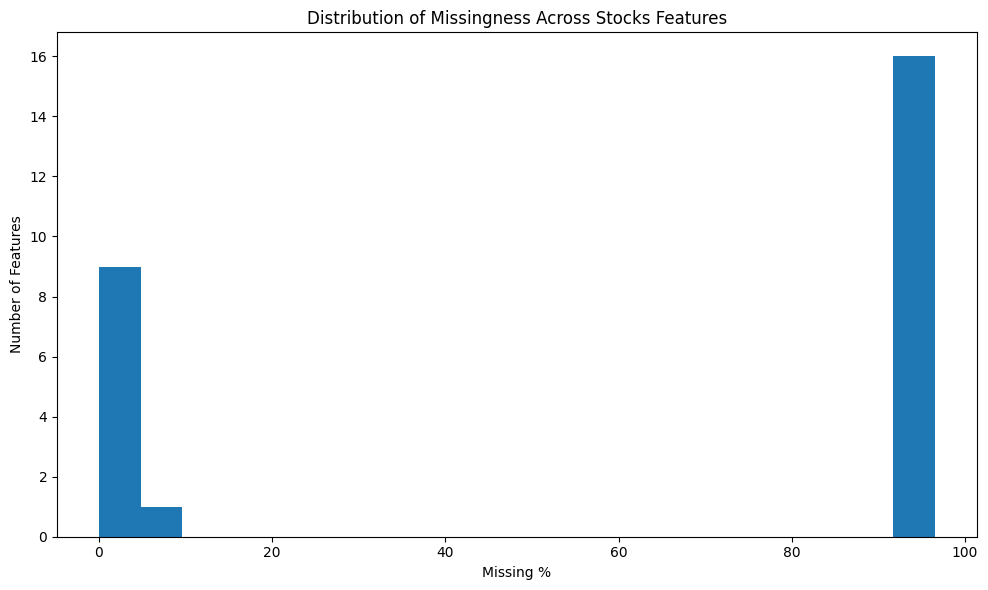

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df_missing["missing_pct"], bins=20)
ax.set_title("Distribution of Missingness Across Stocks Features")
ax.set_xlabel("Missing %")
ax.set_ylabel("Number of Features")
plt.tight_layout()
plt.show()

## Missingness buckets

This helps determine:
- which variables could be imputed
- which variables are too sparse
- which variables might be better summarized

In [9]:
def missing_bucket(x):
    if x == 0:
        return "0%"
    elif x <= 5:
        return "0-5%"
    elif x <= 20:
        return "5-20%"
    elif x <= 50:
        return "20-50%"
    elif x <= 80:
        return "50-80%"
    else:
        return "80%+"

df_missing["missing_bucket"] = df_missing["missing_pct"].apply(missing_bucket)

df_missing_bucket_summary = (
    df_missing.groupby("missing_bucket")
    .size()
    .reset_index(name="n_features")
)

display(df_missing_bucket_summary)

,missing_bucket,n_features
0,0%,9
1,5-20%,1
2,80%+,16


## Numeric distribution screening

For numeric candidates we compute compact summary statistics.
This is useful for:
- spotting skewness / outliers
- identifying threshold candidates for Snorkel
- assessing whether median imputation is sensible

In [10]:
numeric_summary_rows = []

for col in numeric_candidate_cols:
    s = pd.to_numeric(df_stocks[col], errors="coerce")
    non_missing = s.dropna()

    if len(non_missing) == 0:
        continue

    numeric_summary_rows.append({
        "feature": col,
        "missing_pct": s.isna().mean() * 100,
        "n_non_missing": non_missing.shape[0],
        "mean": non_missing.mean(),
        "median": non_missing.median(),
        "std": non_missing.std(),
        "min": non_missing.min(),
        "p01": non_missing.quantile(0.01),
        "p05": non_missing.quantile(0.05),
        "p25": non_missing.quantile(0.25),
        "p50": non_missing.quantile(0.50),
        "p75": non_missing.quantile(0.75),
        "p95": non_missing.quantile(0.95),
        "p99": non_missing.quantile(0.99),
        "max": non_missing.max(),
    })

df_numeric_summary = pd.DataFrame(numeric_summary_rows)

if not df_numeric_summary.empty:
    df_numeric_summary = df_numeric_summary.sort_values("missing_pct", ascending=False)

display(df_numeric_summary)

,feature,missing_pct,n_non_missing,mean,median,std,min,p01,p05,p25,p50,p75,p95,p99,max
5,vol_stability_score,96.503566,1059,4.434962e-01,3.518853e-01,3.464542e-01,0.001046,0.054353,0.143237,2.410462e-01,3.518853e-01,5.394989e-01,1.003977e+00,1.768101e+00,3.464102e+00
7,vol_trend_slope,96.503566,1059,9.955531e-03,4.406723e-03,1.820402e-01,-1.879210,-0.594760,-0.093582,-1.650617e-02,4.406723e-03,2.682984e-02,1.315301e-01,8.031953e-01,2.000000e+00
16,price_trend_slope,96.500264,1060,1.832573e-03,4.812288e-03,5.169678e-02,-0.500087,-0.166209,-0.062579,-1.679530e-02,4.812288e-03,2.358065e-02,5.921545e-02,1.193861e-01,3.175176e-01
2,std_vol,96.500264,1060,4.333830e+08,2.757561e+07,2.113735e+09,0.000000,5.773503,150909.921556,6.341679e+06,2.757561e+07,1.133268e+08,1.428179e+09,9.448888e+09,3.860393e+10
15,price_volatility_score,96.500264,1060,1.225500e-01,1.068828e-01,7.782188e-02,0.000000,0.004852,0.036360,7.180747e-02,1.068828e-01,1.536281e-01,2.654025e-01,3.956380e-01,9.736594e-01
9,market_cap_volatility,96.500264,1060,1.295034e-01,1.094105e-01,8.840182e-02,0.000000,0.004852,0.036707,7.190146e-02,1.094105e-01,1.582672e-01,2.987087e-01,4.798281e-01,6.836264e-01
1,avg_vol,96.487058,1064,1.036793e+09,7.887352e+07,4.979487e+09,0.000000,6.050000,435929.333333,2.058502e+07,7.887352e+07,3.285065e+08,5.023870e+09,1.532434e+10,9.647545e+10
14,avg_closing_price,96.487058,1064,2.720424e+06,1.602239e+02,2.387137e+07,0.099063,0.188793,3.029626,5.114603e+01,1.602239e+02,5.169134e+02,4.163358e+03,1.792825e+08,2.921924e+08
8,avg_market_cap,96.487058,1064,1.620007e+08,1.999680e+07,6.190608e+08,69092.500000,135743.953333,651973.206250,4.031337e+06,1.999680e+07,9.303352e+07,7.008492e+08,1.973967e+09,1.191728e+10
6,vol_shock_ratio,96.487058,1064,3.928002e+01,2.945807e+00,7.694839e+02,0.000000,1.048808,1.421719,2.117816e+00,2.945807e+00,5.162125e+00,1.949203e+01,2.444048e+02,2.469640e+04


## Categorical screening

This is important for possible interpretable Snorkel rules and later feature engineering.

In [11]:
print("Categorical candidate columns:")
print(categorical_candidate_cols)
print("Number of categorical candidate columns:", len(categorical_candidate_cols))

Categorical candidate columns:
['risk_level', 'moodys_risk_rating', 'Shares outstanding', 'Current_market_capitalisation_DKK', 'Risk level_stock_closing_price']
Number of categorical candidate columns: 5


In [12]:
categorical_summary_rows = []

for col in categorical_candidate_cols:
    s = df_stocks[col].astype("string")
    top_values = s.value_counts(dropna=False).head(5)

    categorical_summary_rows.append({
        "feature": col,
        "missing_pct": s.isna().mean() * 100,
        "n_unique": s.nunique(dropna=True),
        "top_1": str(top_values.index[0]) if len(top_values) > 0 else None,
        "top_1_count": int(top_values.iloc[0]) if len(top_values) > 0 else None,
        "top_2": str(top_values.index[1]) if len(top_values) > 1 else None,
        "top_2_count": int(top_values.iloc[1]) if len(top_values) > 1 else None,
    })

if len(categorical_summary_rows) == 0:
    df_categorical_summary = pd.DataFrame(
        columns=[
            "feature",
            "missing_pct",
            "n_unique",
            "top_1",
            "top_1_count",
            "top_2",
            "top_2_count",
        ]
    )
else:
    df_categorical_summary = pd.DataFrame(categorical_summary_rows).sort_values(
        "missing_pct",
        ascending=False
    )

display(df_categorical_summary)

,feature,missing_pct,n_unique,top_1,top_1_count,top_2,top_2_count
0,risk_level,0.0,4,Take caution,19216,Go ahead,5616
1,moodys_risk_rating,0.0,4,Take caution,19216,Go ahead,5616
2,Shares outstanding,0.0,90,n.a.,28864,427.425.574,16
3,Current_market_capitalisation_DKK,0.0,90,n.a.,28864,93.755,16
4,Risk level_stock_closing_price,0.0,4,Take caution,19216,Go ahead,5616


## Snorkel-oriented EDA

The purpose here is to identify variables that can support simple, interpretable rules.
Typical good candidates are:
- risk levels
- negative EPS
- negative price trends
- high beta / volatility stress

In [13]:
snorkel_candidate_cols = [
    c for c in [
        "risk_level",
        "moodys_risk_rating",
        "vol_shock_ratio",
        "vol_trend_slope",
        "market_cap_volatility",
        "Price_trends_52 weeks_%",
        "market_beta_1y",
        "Earnings_per_share_DKK",
        "price_trend_slope",
        "price_volatility_score",
    ]
    if c in df_stocks.columns
]

print("Snorkel candidate columns:")
print(snorkel_candidate_cols)

Snorkel candidate columns:
['risk_level', 'moodys_risk_rating', 'vol_shock_ratio', 'vol_trend_slope', 'market_cap_volatility', 'Price_trends_52 weeks_%', 'market_beta_1y', 'Earnings_per_share_DKK', 'price_trend_slope', 'price_volatility_score']


In [14]:
for col in [c for c in ["risk_level", "moodys_risk_rating", "supplier_sector"] if c in df_stocks.columns]:
    print(f"\n=== {col} ===")
    display(df_stocks[col].astype("string").value_counts(dropna=False).to_frame("count"))


=== risk_level ===


,count
risk_level,
Take caution,19216
Go ahead,5616
Do not source,5360
No data,96



=== moodys_risk_rating ===


,count
moodys_risk_rating,
Take caution,19216
Go ahead,5616
Do not source,5360
No data,96



=== supplier_sector ===


,count
supplier_sector,
Business Services,8192
Wholesale,4480
"Chemicals, Petroleum, Rubber & Plastic",3056
Construction,2352
"Industrial, Electric & Electronic Machinery",1984
<NA>,1824
Computer Software,1312
Biotechnology and Life Sciences,896
Metals & Metal Products,816


In [15]:
if not df_numeric_summary.empty:
    df_snorkel_thresholds = df_numeric_summary[
        df_numeric_summary["feature"].isin(
            [c for c in snorkel_candidate_cols if c in df_numeric_summary["feature"].values]
        )
    ].copy()
else:
    df_snorkel_thresholds = pd.DataFrame()

display(df_snorkel_thresholds)

,feature,missing_pct,n_non_missing,mean,median,std,min,p01,p05,p25,p50,p75,p95,p99,max
7,vol_trend_slope,96.503566,1059,0.009956,0.004407,1.820402e-01,-1.879210,-0.594760,-0.093582,-0.016506,0.004407,0.026830,0.131530,8.031953e-01,2.000000e+00
16,price_trend_slope,96.500264,1060,0.001833,0.004812,5.169678e-02,-0.500087,-0.166209,-0.062579,-0.016795,0.004812,0.023581,0.059215,1.193861e-01,3.175176e-01
15,price_volatility_score,96.500264,1060,0.122550,0.106883,7.782188e-02,0.000000,0.004852,0.036360,0.071807,0.106883,0.153628,0.265403,3.956380e-01,9.736594e-01
9,market_cap_volatility,96.500264,1060,0.129503,0.109410,8.840182e-02,0.000000,0.004852,0.036707,0.071901,0.109410,0.158267,0.298709,4.798281e-01,6.836264e-01
6,vol_shock_ratio,96.487058,1064,39.280018,2.945807,7.694839e+02,0.000000,1.048808,1.421719,2.117816,2.945807,5.162125,19.492026,2.444048e+02,2.469640e+04
10,Price_trends_52 weeks_%,95.404120,1392,10.505747,2.000000,4.108405e+01,-59.000000,-59.000000,-44.000000,-18.000000,2.000000,30.000000,75.000000,1.970000e+02,1.970000e+02
11,market_beta_1y,95.404120,1392,0.609195,1.000000,5.543127e-01,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,2.000000e+00,2.000000e+00
12,Earnings_per_share_DKK,95.404120,1392,427837.275862,5.000000,3.968570e+06,-144.000000,-144.000000,-15.000000,0.000000,5.000000,18.000000,143.000000,3.721762e+07,3.721762e+07


## Imputation-oriented EDA

This section is not about fitting imputation yet.
It is about deciding whether imputation is even reasonable.

In [16]:
df_imputation_candidates = df_structure.copy()

def imputation_recommendation(row):
    missing_pct = row["missing_pct"]
    dtype = row["dtype"]

    if missing_pct == 0:
        return "no imputation needed"
    if missing_pct > 85:
        return "too sparse; prefer missing flag / view indicator / summary"
    if "float" in dtype or "int" in dtype:
        if missing_pct <= 50:
            return "median impute + missing flag"
        return "consider summary feature + missing flag"
    if "object" in dtype or "string" in dtype:
        return "missing category / explicit unknown"
    return "inspect manually"

df_imputation_candidates["imputation_recommendation"] = df_imputation_candidates.apply(
    imputation_recommendation,
    axis=1,
)

display(df_imputation_candidates.sort_values("missing_pct", ascending=False))

,feature,dtype,missing_pct,n_unique,imputation_recommendation
0,vol_stability_score,float64,96.503566,1056,too sparse; prefer missing flag / view indicat...
1,vol_trend_slope,float64,96.503566,1057,too sparse; prefer missing flag / view indicat...
2,std_vol,float64,96.500264,1056,too sparse; prefer missing flag / view indicat...
3,market_cap_volatility,float64,96.500264,1060,too sparse; prefer missing flag / view indicat...
4,price_volatility_score,float64,96.500264,1060,too sparse; prefer missing flag / view indicat...
5,price_trend_slope,float64,96.500264,1060,too sparse; prefer missing flag / view indicat...
6,min_vol,float64,96.487058,1051,too sparse; prefer missing flag / view indicat...
7,max_vol,float64,96.487058,1053,too sparse; prefer missing flag / view indicat...
8,vol_shock_ratio,float64,96.487058,1053,too sparse; prefer missing flag / view indicat...
9,avg_vol,float64,96.487058,1059,too sparse; prefer missing flag / view indicat...


## Feature-engineering-oriented EDA

This section identifies raw stocks columns that may be better converted into more robust engineered signals.

In [17]:
feature_engineering_candidate_cols = [
    c for c in [
        "avg_vol",
        "std_vol",
        "max_vol",
        "min_vol",
        "vol_stability_score",
        "vol_shock_ratio",
        "vol_trend_slope",
        "avg_market_cap",
        "market_cap_volatility",
        "Price_trends_52 weeks_%",
        "market_beta_1y",
        "Earnings_per_share_DKK",
        "Book_value_per_share_DKK",
        "Shares outstanding",
        "Current_market_capitalisation_DKK",
        "avg_closing_price",
        "price_volatility_score",
        "price_trend_slope",
    ]
    if c in df_stocks.columns
]

print(feature_engineering_candidate_cols)

['avg_vol', 'std_vol', 'max_vol', 'min_vol', 'vol_stability_score', 'vol_shock_ratio', 'vol_trend_slope', 'avg_market_cap', 'market_cap_volatility', 'Price_trends_52 weeks_%', 'market_beta_1y', 'Earnings_per_share_DKK', 'Book_value_per_share_DKK', 'Shares outstanding', 'Current_market_capitalisation_DKK', 'avg_closing_price', 'price_volatility_score', 'price_trend_slope']


In [18]:
df_corr_input = df_stocks[feature_engineering_candidate_cols].copy()

for col in df_corr_input.columns:
    df_corr_input[col] = pd.to_numeric(df_corr_input[col], errors="coerce")

df_corr = df_corr_input.corr(numeric_only=True)

display(df_corr)

,avg_vol,std_vol,max_vol,min_vol,vol_stability_score,vol_shock_ratio,vol_trend_slope,avg_market_cap,market_cap_volatility,Price_trends_52 weeks_%,market_beta_1y,Earnings_per_share_DKK,Book_value_per_share_DKK,Shares outstanding,Current_market_capitalisation_DKK,avg_closing_price,price_volatility_score,price_trend_slope
avg_vol,1.000000,0.809474,0.944980,0.952531,-0.016043,0.004337,0.013047,0.081394,0.063338,0.221782,-0.024041,-0.024454,-0.022639,NaN,0.326509,-0.023749,0.088074,0.072303
std_vol,0.809474,1.000000,0.944912,0.614931,0.097592,0.020065,0.004160,0.026179,0.086208,0.290269,0.000613,-0.024124,-0.023108,NaN,0.335607,-0.023431,0.121277,0.032973
max_vol,0.944980,0.944912,1.000000,0.823359,0.048496,0.010175,0.000829,0.051352,0.082116,0.277805,-0.013739,-0.025460,-0.023925,NaN,0.343487,-0.024728,0.111935,0.051260
min_vol,0.952531,0.614931,0.823359,1.000000,-0.065098,-0.008586,0.019556,0.108666,0.034931,0.163081,-0.031694,-0.021611,-0.019422,NaN,0.298285,-0.020988,0.050433,0.095396
vol_stability_score,-0.016043,0.097592,0.048496,-0.065098,1.000000,0.072761,0.003630,-0.114955,0.191468,0.168689,0.157373,0.447843,0.448405,NaN,0.169284,0.432076,0.221114,-0.057384
vol_shock_ratio,0.004337,0.020065,0.010175,-0.008586,0.072761,1.000000,-0.006386,-0.012049,0.040527,-0.010820,0.026147,-0.004197,-0.004285,NaN,0.165261,-0.004142,0.048482,0.011840
vol_trend_slope,0.013047,0.004160,0.000829,0.019556,0.003630,-0.006386,1.000000,-0.040378,-0.090842,0.041870,0.077611,0.047532,0.047472,NaN,0.187133,0.070114,-0.099130,0.222313
avg_market_cap,0.081394,0.026179,0.051352,0.108666,-0.114955,-0.012049,-0.040378,1.000000,-0.066895,0.060463,-0.077474,-0.030404,-0.027937,NaN,0.712134,-0.029487,0.022292,-0.043357
market_cap_volatility,0.063338,0.086208,0.082116,0.034931,0.191468,0.040527,-0.090842,-0.066895,1.000000,0.085541,0.011647,-0.048087,-0.049683,NaN,-0.560809,-0.049247,0.810656,0.013556
Price_trends_52 weeks_%,0.221782,0.290269,0.277805,0.163081,0.168689,-0.010820,0.041870,0.060463,0.085541,1.000000,0.123960,0.046561,0.046276,NaN,0.638758,0.051253,0.113214,0.117472


In [19]:
high_corr_pairs = []

if not df_corr.empty:
    corr_matrix = df_corr.abs()
    for i, col1 in enumerate(corr_matrix.columns):
        for col2 in corr_matrix.columns[i+1:]:
            corr_val = corr_matrix.loc[col1, col2]
            if pd.notna(corr_val) and corr_val >= 0.80:
                high_corr_pairs.append({
                    "feature_1": col1,
                    "feature_2": col2,
                    "abs_corr": corr_val,
                })

df_high_corr_pairs = pd.DataFrame(high_corr_pairs).sort_values("abs_corr", ascending=False) if high_corr_pairs else pd.DataFrame(columns=["feature_1", "feature_2", "abs_corr"])
display(df_high_corr_pairs)

,feature_1,feature_2,abs_corr
6,Earnings_per_share_DKK,Book_value_per_share_DKK,1.000000
7,Earnings_per_share_DKK,avg_closing_price,0.987142
8,Book_value_per_share_DKK,avg_closing_price,0.987139
2,avg_vol,min_vol,0.952531
1,avg_vol,max_vol,0.944980
3,std_vol,max_vol,0.944912
4,max_vol,min_vol,0.823359
5,market_cap_volatility,price_volatility_score,0.810656
0,avg_vol,std_vol,0.809474


## Final decision table

This is the most important output of the notebook.

Each feature gets an initial recommendation for:
- Snorkel suitability
- imputation strategy
- feature engineering action

In [20]:
df_feature_decisions = df_structure.copy()

snorkel_candidate_set = set(snorkel_candidate_cols)

def snorkel_flag(feature):
    return "yes" if feature in snorkel_candidate_set else "no"

def feature_engineering_decision(row):
    feature = row["feature"]
    missing_pct = row["missing_pct"]

    if feature in snorkel_candidate_set and missing_pct <= 85:
        return "engineer interpretable flags / thresholds / summaries"
    if missing_pct > 85:
        return "drop raw / summarize if important"
    if missing_pct > 50:
        return "keep only if strong business relevance"
    return "keep or engineer"

df_feature_decisions["snorkel_candidate"] = df_feature_decisions["feature"].apply(snorkel_flag)
df_feature_decisions = df_feature_decisions.merge(
    df_imputation_candidates[["feature", "imputation_recommendation"]],
    on="feature",
    how="left",
)
df_feature_decisions["feature_engineering_decision"] = df_feature_decisions.apply(
    feature_engineering_decision,
    axis=1,
)

display(df_feature_decisions.sort_values(["snorkel_candidate", "missing_pct"], ascending=[False, False]))

,feature,dtype,missing_pct,n_unique,snorkel_candidate,imputation_recommendation,feature_engineering_decision
1,vol_trend_slope,float64,96.503566,1057,yes,too sparse; prefer missing flag / view indicat...,drop raw / summarize if important
3,market_cap_volatility,float64,96.500264,1060,yes,too sparse; prefer missing flag / view indicat...,drop raw / summarize if important
4,price_volatility_score,float64,96.500264,1060,yes,too sparse; prefer missing flag / view indicat...,drop raw / summarize if important
5,price_trend_slope,float64,96.500264,1060,yes,too sparse; prefer missing flag / view indicat...,drop raw / summarize if important
8,vol_shock_ratio,float64,96.487058,1053,yes,too sparse; prefer missing flag / view indicat...,drop raw / summarize if important
13,market_beta_1y,float64,95.404120,3,yes,too sparse; prefer missing flag / view indicat...,drop raw / summarize if important
14,Earnings_per_share_DKK,float64,95.404120,47,yes,too sparse; prefer missing flag / view indicat...,drop raw / summarize if important
15,Price_trends_52 weeks_%,float64,95.404120,70,yes,too sparse; prefer missing flag / view indicat...,drop raw / summarize if important
17,risk_level,str,0.000000,4,yes,no imputation needed,engineer interpretable flags / thresholds / su...
18,moodys_risk_rating,str,0.000000,4,yes,no imputation needed,engineer interpretable flags / thresholds / su...


## Save EDA outputs

These outputs can be reused later in:
- Snorkel notebook
- feature engineering notebook
- modeling discussion

In [21]:
save_processed(df_structure, "stocks_eda_structure.csv")
save_processed(df_missing, "stocks_eda_missingness.csv")
save_processed(df_numeric_summary, "stocks_eda_numeric_summary.csv")
save_processed(df_categorical_summary, "stocks_eda_categorical_summary.csv")
save_processed(df_imputation_candidates, "stocks_eda_imputation_candidates.csv")
save_processed(df_feature_decisions, "stocks_eda_feature_decisions.csv")
save_processed(df_high_corr_pairs, "stocks_eda_high_corr_pairs.csv")

print("Saved stocks EDA outputs to Data/processed/")

Saved stocks EDA outputs to Data/processed/


## Short interpretation notes

Use this section to summarize:
- which stocks / market variables are strong LF candidates
- which variables are too sparse for direct use
- where missingness itself is informative
- which raw variables should later be converted into engineered market stress / trend signals